In [1]:
import time
import warnings
import itertools
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

warnings.filterwarnings("ignore")
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Outline
---

<big>

- Explore
    - Plot the data
    - Clean outliers
    - Impute missing values if needed

- Transform
    - Take the natural log if needed

- Decompose your data
    - Check if the time-series has any **overall trend** or **seasonality**?
    - Plot the decomposed series
    - If you're fitting an ARIMA model, remove seasonality

- Check for Stationarity and find $d$
    - Is the series stationary?
    - Run the Augmented Dickey Fuller test, 
    - Determine **order of differencing** needed to stationarize the series
    - Check ACF & PACF plots to 

- Autocorrelations and find $p, q$
    - Choose $p, q$ of the ARIMA by examining ACF and PACF plots

- Fit ARIMA/SARIMAX model over a grid
    - Use pdq and set up a grid search
    - Find the best model using
        - AIC/BIC
        - Out of Sample Prediction Error
    - Check your Residuals, they should be ~$N(0, 1)$ and look like white noise

- Make predictions

----

- Note that ARIMA models assume non-seasonal series,
    - need to de-seasonalize the series before modeling


In [2]:
from sktime.datasets.forecasting import Airline
dataset = Airline()
y = dataset.load("y").resample('M').mean()

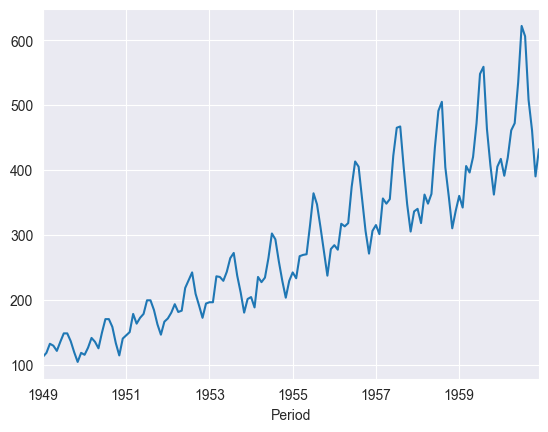

In [3]:
y.plot();

## Split the data

In [4]:
split_pt = int(len(y) * 0.7)

tr = y.iloc[:split_pt]
te = y.iloc[split_pt:]

print(len(tr), len(te))

100 44


<Axes: xlabel='Period'>

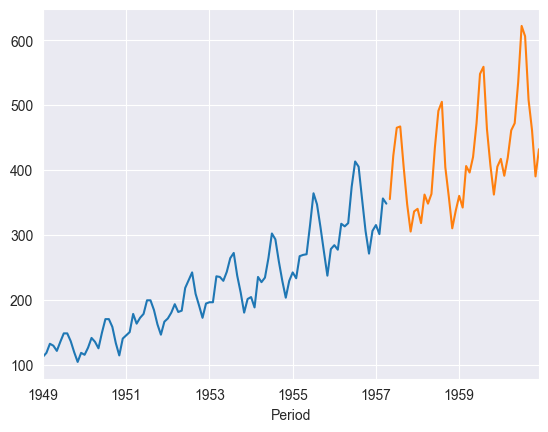

In [5]:
tr.plot()
te.plot()

In [6]:
import statsmodels.tsa.api as smt

In [7]:
y.index = [i.to_timestamp() for i in y.index]

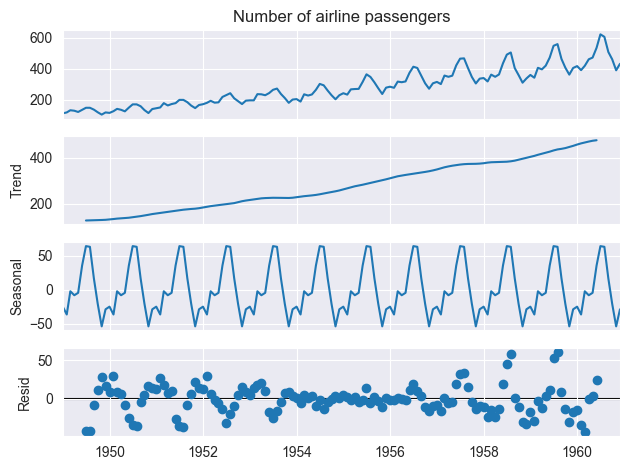

In [8]:

smt.seasonal_decompose(y).plot();

## Grid Search

**Considerations when setting up the parameter grid**

- If your ts is stationary, use d = 0
- If your ts is not stationary, first figure out the value of d using ACF, PACF plots
- Do you need to use `log(y)`

----

In [10]:
p = q = d = range(2)
pdq = list(itertools.product(p, d, q))
PDQ = [tuple(list(x) + [12]) for x in pdq]
pdqPDQs = list(itertools.product(pdq, PDQ))

errors = []
results = {}

print("Searching through {} parameter combinations.".format(len(pdqPDQs)))

t0 = time.time()
for i, order in enumerate(pdqPDQs):
    """
    """
    
    try:
        model = SARIMAX(tr, order=order[0], seasonal_order=order[1]).fit()
        results[order] = model.aic
    except:
        errors.append(order)
        
print("Search completed in {} seconds".format(round(time.time() - t0, 2)))
print("{} errors were suppressed.".format(len(errors)))

Searching through 64 parameter combinations.
Search completed in 2.35 seconds
0 errors were suppressed.


In [11]:
results

{((0, 0, 0), (0, 0, 0, 12)): np.float64(1373.8462167802222),
 ((0, 0, 0), (0, 0, 1, 12)): np.float64(1279.5793639235326),
 ((0, 0, 0), (0, 1, 0, 12)): np.float64(865.6872857545325),
 ((0, 0, 0), (0, 1, 1, 12)): np.float64(831.750993928145),
 ((0, 0, 0), (1, 0, 0, 12)): np.float64(1034.5531294481239),
 ((0, 0, 0), (1, 0, 1, 12)): np.float64(1001.098163838781),
 ((0, 0, 0), (1, 1, 0, 12)): np.float64(796.8329228886637),
 ((0, 0, 0), (1, 1, 1, 12)): np.float64(777.5656832834313),
 ((0, 0, 1), (0, 0, 0, 12)): np.float64(1244.5005227417662),
 ((0, 0, 1), (0, 0, 1, 12)): np.float64(1151.640118361016),
 ((0, 0, 1), (0, 1, 0, 12)): np.float64(790.7180741932002),
 ((0, 0, 1), (0, 1, 1, 12)): np.float64(774.3532522469528),
 ((0, 0, 1), (1, 0, 0, 12)): np.float64(953.6118233007971),
 ((0, 0, 1), (1, 0, 1, 12)): np.float64(950.3768502144493),
 ((0, 0, 1), (1, 1, 0, 12)): np.float64(757.7601541946013),
 ((0, 0, 1), (1, 1, 1, 12)): np.float64(735.919032484168),
 ((0, 1, 0), (0, 0, 0, 12)): np.float6

## The best model

In [12]:
best_params = pd.Series(results).sort_values().reset_index().iloc[0].iloc[:2]
best_params.index = ['pdq', 'PDQs']
print("Fitting the best model using the params \n(p, d, q) = {} and \n(P, D, Q, s) = {}\n\n".format(best_params['pdq'], best_params['PDQs']))

Fitting the best model using the params 
(p, d, q) = (1, 1, 0) and 
(P, D, Q, s) = (1, 1, 0, 12)




In [13]:
best_model = SARIMAX(tr, 
                     order=best_params['pdq'], 
                     seasonal_order=best_params['PDQs']).fit()
print(best_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:       Number of airline passengers   No. Observations:                  100
Model:             SARIMAX(1, 1, 0)x(1, 1, 0, 12)   Log Likelihood                -319.101
Date:                            Wed, 19 Nov 2025   AIC                            644.203
Time:                                    17:37:47   BIC                            651.601
Sample:                                01-31-1949   HQIC                           647.182
                                     - 04-30-1957                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2434      0.097     -2.512      0.012      -0.433      -0.054
ar.S.L12      -0.2127      0.087   

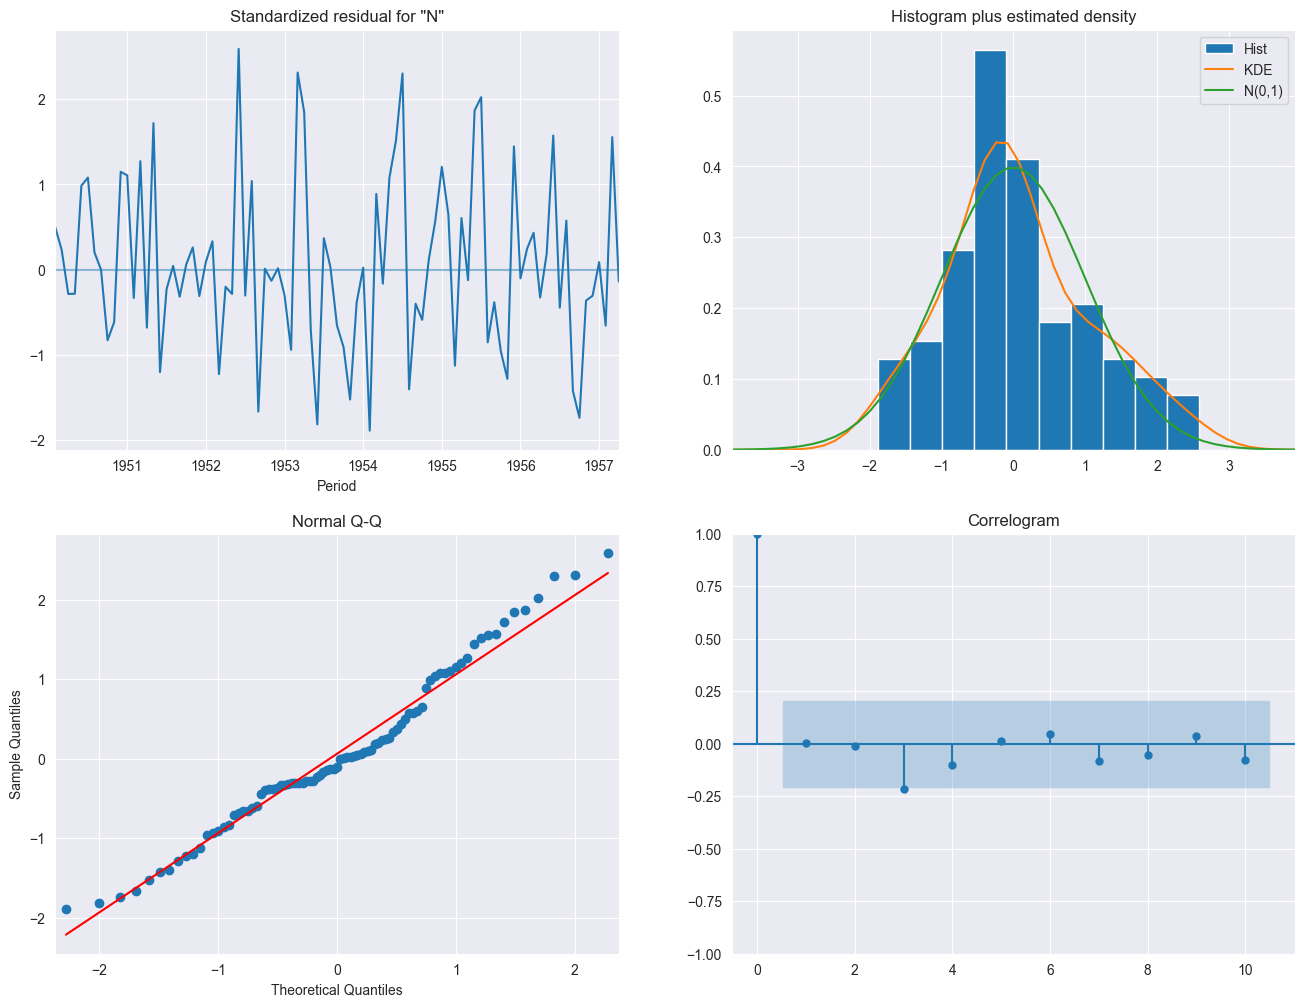

In [14]:
best_model.plot_diagnostics(figsize=(16, 12));

## Train Error

In [15]:
split = int(0.2 * len(tr))

# predict on the last 20 values of the training period
# these are one-step-ahead
yhat_tr = best_model.get_prediction(start=tr.index.tolist()[-split], dynamic=False)

yhat_tr_ci = yhat_tr.conf_int()
yhat_mean_tr = yhat_tr.predicted_mean
yhat_mean_tr.name = 'mean_value_tr'

mse_tr = mean_squared_error(y_true=tr[-split:], y_pred=yhat_mean_tr)
print("The train error is {}.".format(round(mse_tr, 4)))

The train error is 72.8372.


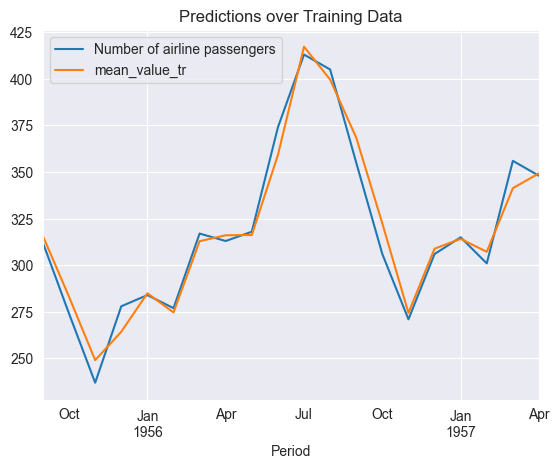

In [16]:
pd.concat([tr[-split:], yhat_mean_tr], axis=1).plot(title="Predictions over Training Data");

### Out - of - Sample Prediction

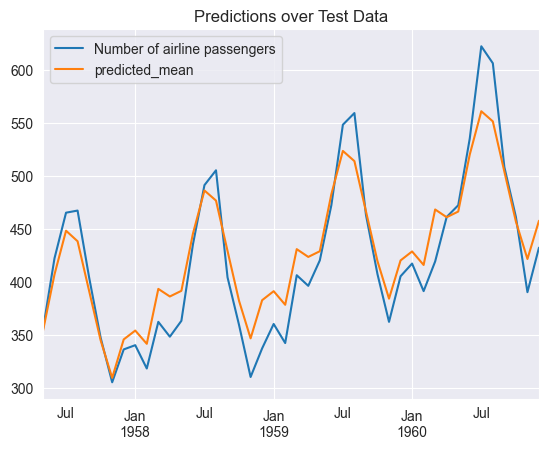

In [17]:
yhat_oos = best_model.get_forecast(steps=len(te))

yhat_oos_mean = yhat_oos.predicted_mean
yhat_oos_cnfi = yhat_oos.conf_int()

pd.concat([te, yhat_oos_mean], axis=1).dropna().plot(title='Predictions over Test Data');

In [18]:
mse_te = mean_squared_error(te, yhat_oos_mean)
print("The test error is {}".format(round(mse_te, 2)))

The test error is 686.75


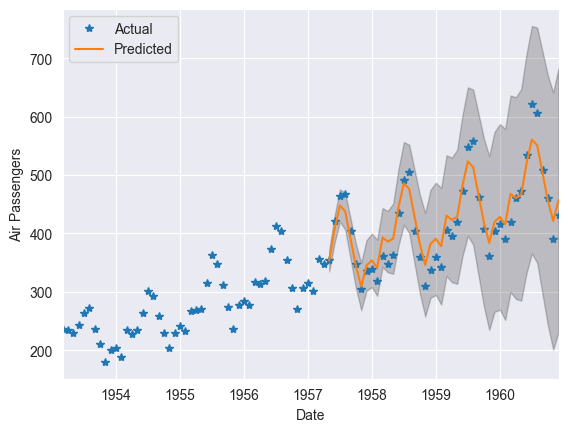

In [19]:
ax = y[50:].plot.line(label='Actual', style='*')
yhat_oos_mean.plot(ax=ax, label='Predicted')
ax.fill_between(yhat_oos_cnfi.index, 
                yhat_oos_cnfi.iloc[:, 0], 
                yhat_oos_cnfi.iloc[:, 1], color='k', alpha=0.2)

ax.set_xlabel('Date')
ax.set_ylabel('Air Passengers')

plt.legend()
plt.show()